[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/firefly1248/demo-notebooks/blob/main/notebooks/score_sensitivity_venn_abers.ipynb)

# How large a week-over-week move in a propensity score means anything

A churn or cross-sell score moves five percentage points for a customer between two weekly runs.
Before explaining that move it is worth asking whether it is larger than the move the same customer
would have shown with nothing about them changed at all.

That floor is measurable. Refit the model the way production does, on a training window that has
rolled forward, and score the same unchanged customer again. Whatever the score does is noise, and
its spread is the smallest move worth interpreting.

This notebook measures the floor, checks what moves it, and asks whether a Venn-Abers interval, the
standard calibrated interval for a classifier score, tells you which customers sit above it.

Runtime is about three minutes on a laptop CPU and longer on a free Colab runtime.

In [1]:
try:
    import catboost, venn_abers
except ImportError:
    !pip install -q catboost venn-abers

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from scipy.special import expit, logit
from scipy.stats import ConstantInputWarning, spearmanr
from sklearn.neighbors import NearestNeighbors
from venn_abers import VennAbers

# a band where a predictor takes one value leaves the rank correlation undefined, which is handled
warnings.filterwarnings("ignore", category=ConstantInputWarning)

## The stand

Five features on the unit interval. Three drive the true probability of the label, two drive
nothing.

| Feature | Role |
|---|---|
| `x_move` | drives the probability; this is the one that moves in the second arm |
| `x_sparse` | drives the probability, drawn from a skewed distribution so its upper range is thinly covered |
| `x_extra` | drives the probability through a bend, so the model has real work to do |
| `x_inert1`, `x_inert2` | enter nothing |

`x_sparse` is there so that epistemic uncertainty varies between rows for a reason other than the
score itself. Two customers can share a score of 0.4 with one of them sitting in a thin part of the
feature space and the other in a dense part, which is what makes the question "which customers are
noisy" non-trivial.

A further `CAL_SHARE` of the training size is drawn to calibrate, so that when the training set is
swept the calibration set grows with it and the sweep means "more data" rather than "more data in
one of the two places". Nothing here is tuned; the subject is the floor, not the model.

In [3]:
FEATURES = ["x_sparse", "x_move", "x_extra", "x_inert1", "x_inert2"]
DRIVERS = ["x_sparse", "x_move", "x_extra"]     # the three that enter the probability
N_TRAIN, N_TEST = 8000, 3000
CAL_SHARE = 0.5     # calibration rows as a share of the training rows, so both scale together
PAIRS = 24
LEVER_PAIRS = PAIRS // 2                        # the sweeps are wider, so they run at half the depth
MOVE, COEF = 0.05, 4.0
SHARED = [0.0, 0.5, 0.9, 0.98]
SIZES = [2000, 8000, 32000, 128000]
COHORTS = [1, 10, 50, 200]
COHORT_DRAWS, PERMUTATIONS = 500, 200
ROLL = 0.9          # share of the training window a weekly refresh carries over
NOTHING = "nothing changed"


def true_p(x):
    return expit(COEF * (x.x_move - 0.5) + 2.5 * (x.x_sparse - 0.3) + np.sin(2 * np.pi * x.x_extra))


def draw(n, rng):
    x = pd.DataFrame(rng.uniform(size=(n, len(FEATURES))), columns=FEATURES)
    x["x_sparse"] = rng.beta(2, 6, n)
    return x, (rng.uniform(size=n) < true_p(x)).astype(int).values


def n_cal(n_train):
    return int(n_train * CAL_SHARE)


def score(Xtr, ytr, Xc, yc, targets, seed):
    # one fit, then a Venn-Abers calibration on held-out rows; returns p and the interval per target
    m = CatBoostClassifier(iterations=400, learning_rate=0.08, depth=6, random_seed=seed,
                           verbose=0, allow_writing_files=False).fit(Xtr, ytr)
    va = VennAbers().fit(m.predict_proba(Xc), yc)
    out = []
    for T in targets:
        p, ab = va.predict_proba(m.predict_proba(T))
        out.append((p[:, 1], ab[:, 1] - ab[:, 0]))
    return out

## The test customers

The second arm needs a move whose size is known on the probability scale, not on the feature scale,
so `x_move` is shifted by exactly the amount that raises each customer's true probability by five
points. Customers are kept only where that shift stays inside the training range, which also drops
the extremes where a five point rise is not defined.

In [4]:
rng = np.random.default_rng(0)
Xte, _ = draw(N_TEST, rng)
p_true = true_p(Xte)
keep = (p_true.between(0.10, 0.85) & Xte.x_move.between(0.15, 0.85)).values
Xte, p_true = Xte[keep].reset_index(drop=True), p_true[keep].reset_index(drop=True)

moved = Xte.copy()
moved["x_move"] = Xte.x_move + (logit(p_true + MOVE) - logit(p_true)) / COEF
print(f"{len(Xte)} test customers, true probability from {p_true.min():.2f} to {p_true.max():.2f}")
print(f"shifted x_move stays in [{moved.x_move.min():.2f}, {moved.x_move.max():.2f}], "
      f"inside the [0, 1] range the model was trained on")
print(f"true probability after the move rises by exactly {(true_p(moved) - p_true).mean():.3f} "
      f"for every customer")

1945 test customers, true probability from 0.10 to 0.85
shifted x_move stays in [0.21, 0.95], inside the [0, 1] range the model was trained on
true probability after the move rises by exactly 0.050 for every customer


## The floor

Two arms, run on the same pairs of weeks so they see identical refit noise.

- **nothing changed** — the customer's features are the same in both weeks; only the model was refit
- **true probability up five points** — week two uses the shifted features

A week is one refit on a training window that has carried over `ROLL` of last week's rows. The
CatBoost seed is held fixed inside a pair, so the whole movement comes from the data rolling
forward rather than from a different random draw inside the fitting routine.

Because both arms share week one, the rise has a known sign, and the rule that follows is one-sided:
flag a customer whose score went **up** by more than a threshold. That threshold is the 95th
percentile of the signed move when nothing changed, so by construction it flags five percent of
unchanged customers and every rule below can be compared on what it catches.

In [5]:
def roll(X, y, share, rng):
    # replace the share of rows that fall out of the window with fresh ones
    swap = rng.uniform(size=len(X)) >= share
    Xn, yn = draw(int(swap.sum()), rng)
    X2, y2 = X.copy(), y.copy()
    X2.loc[swap, :] = Xn.values
    y2[swap] = yn
    return X2, y2


def weeks(n_train, share, pairs, rng, targets):
    # week-one and week-two scores for each target, one row per pair
    one, two = [], []
    for k in range(pairs):
        Xtr, ytr = draw(n_train, rng)
        Xc, yc = draw(n_cal(n_train), rng)
        one.append([p for p, _ in score(Xtr, ytr, Xc, yc, targets, k)])
        two.append([p for p, _ in score(*roll(Xtr, ytr, share, rng),
                                        *roll(Xc, yc, share, rng), targets, k)])
    one, two = np.array(one), np.array(two)
    return [(one[:, i], two[:, i]) for i in range(len(targets))]


def arms(one, two_same, two_moved):
    # both arms share week one, so the only difference between them is the true five point rise
    move, rise = two_same - one, two_moved - one
    size = np.abs(move)
    return {"median move": np.median(size), "95th percentile move": np.quantile(size, 0.95),
            "real rises caught": (rise > np.quantile(move, 0.95)).mean()}

In [6]:
rng = np.random.default_rng(1)
(one, two_same), (_, two_moved) = weeks(N_TRAIN, ROLL, PAIRS, rng, [Xte, moved])
move, rise = two_same - one, two_moved - one
size = np.abs(move)
base = arms(one, two_same, two_moved)
floor = base["95th percentile move"]

drift = move.mean(axis=1)                       # the whole book moving together in a given week
book = np.quantile(np.abs(drift), 0.95)         # the level averaging customers cannot get below

print(f"week-over-week move with {NOTHING}, over {PAIRS} pairs of weeks:")
print(f"  median size                                   {base['median move']:.3f}")
print(f"  95th percentile size                          {floor:.3f}")
print(f"  share of customers moving at least {MOVE:.2f}       {(size >= MOVE).mean():.2f}")
print()
print(f"averaged over every customer, the model registers the true {MOVE:.2f} rise as "
      f"{rise.mean():.3f}")
print(f"in 95% of weeks the whole book drifts together by less than {book:.4f}")

/Users/ilia.ekhlakov/Library/Python/3.9/lib/python/site-packages/venn_abers/venn_abers.py:112: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


week-over-week move with nothing changed, over 24 pairs of weeks:
  median size                                   0.042
  95th percentile size                          0.148
  share of customers moving at least 0.05       0.43

averaged over every customer, the model registers the true 0.05 rise as 0.046
in 95% of weeks the whole book drifts together by less than 0.0073


Now put the interval next to that. Venn-Abers is the standard calibrated interval for a classifier
score, and it is the natural thing to reach for when someone asks how certain a score is.

In [7]:
rng = np.random.default_rng(2)
Xtr, ytr = draw(N_TRAIN, rng)
Xc, yc = draw(n_cal(N_TRAIN), rng)
p0, width0 = score(Xtr, ytr, Xc, yc, [Xte], 0)[0]

print(f"venn-abers interval width, mean over customers: {width0.mean():.4f}")
print(f"week-over-week move with {NOTHING}, median:     {np.median(size):.4f}")
print(f"the median move is {np.median(size) / width0.mean():.0f}x the width, and the "
      f"95th percentile is {floor / width0.mean():.0f}x")

venn-abers interval width, mean over customers: 0.0081
week-over-week move with nothing changed, median:     0.0418
the median move is 5x the width, and the 95th percentile is 18x


The interval is narrower than the noise by more than an order of magnitude, and read as "how much
could this score be off by" it is badly misleading.

It is not wrong, though, and the reason matters. Venn-Abers answers a different question: given this
fitted model and this score, what is the calibrated probability of the label, and how much does the
calibration set leave undetermined. It is a statement about the mapping from score to probability.
The week-over-week move is a statement about the score itself, which changes when the model is
refit. Nothing in a calibration method sees that, because the model is a fixed input to it.

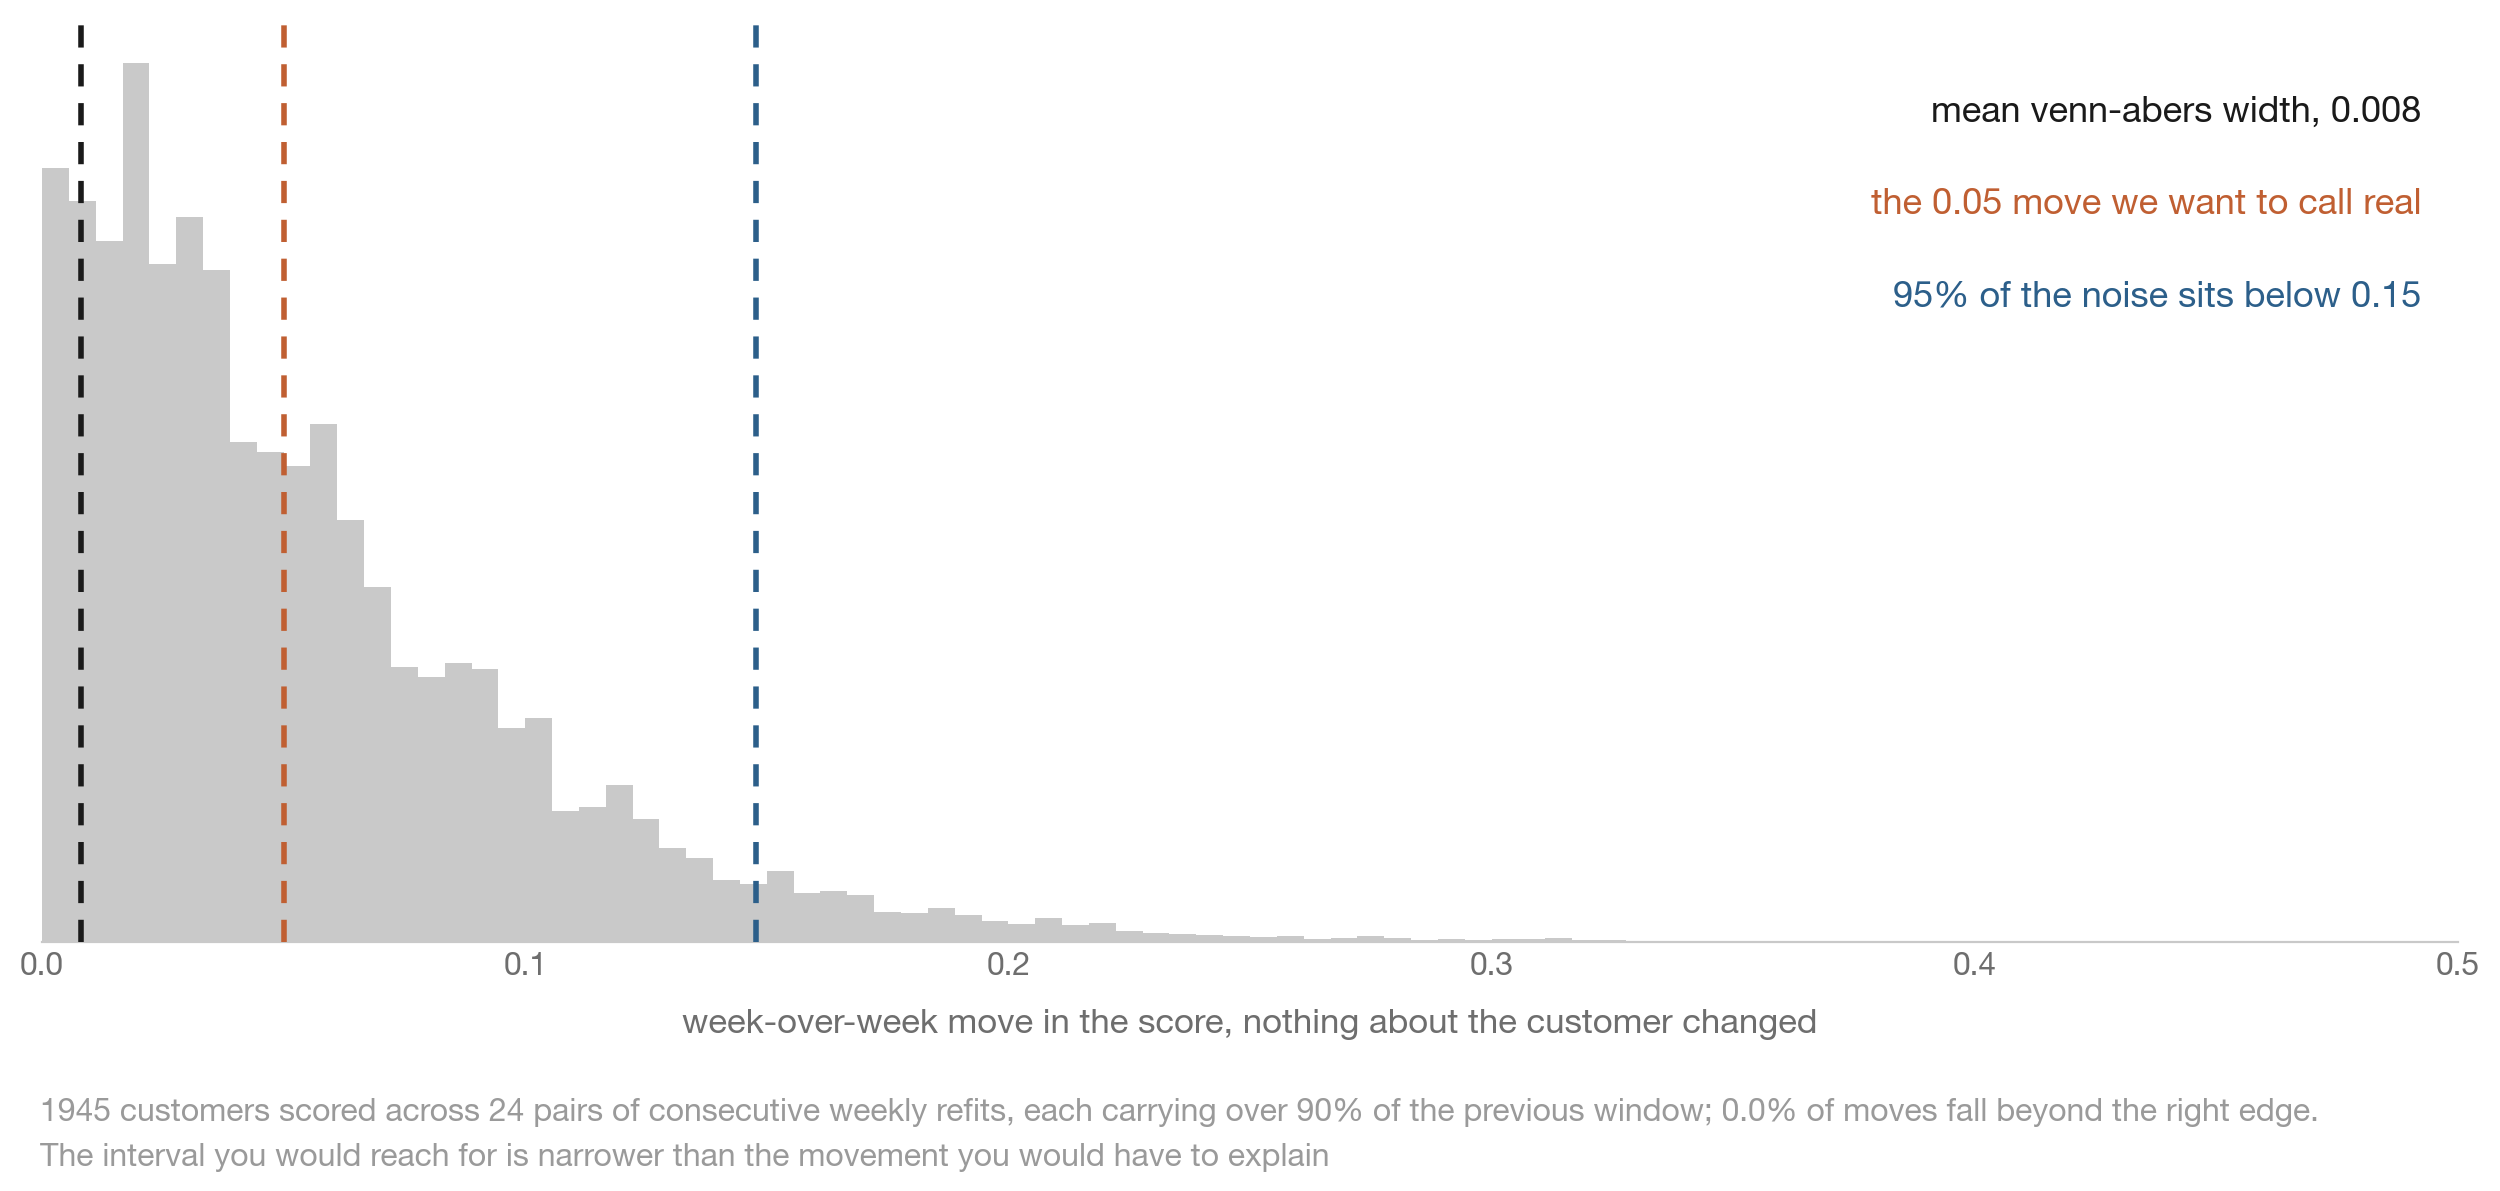

In [8]:
INK, TEXT_MUTED, TEXT_FAINT = "#1a1a1a", "#6e6e6e", "#9a9a9a"
BLUE_E, CORAL_E, GREY_E = "#2C5F8A", "#C05F32", "#c9c9c9"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"]


def clean(ax):
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(GREY_E)
    ax.tick_params(length=0, labelsize=11.5, colors=TEXT_MUTED)
    ax.grid(axis="y", color="#ececec", lw=0.9, zorder=0)
    ax.set_axisbelow(True)


def finish(fig, name, note, y=-0.08):
    fig.text(0.02, y, note, ha="left", va="center", fontsize=11.5, color=TEXT_FAINT,
             linespacing=1.7)
    fig.tight_layout()
    fig.savefig(name, facecolor="white", bbox_inches="tight")
    plt.show()


fig, ax = plt.subplots(figsize=(12.6, 5.4), dpi=200)
ax.hist(size.ravel(), bins=90, range=(0, 0.5), color=GREY_E, zorder=2)
for i, (v, colour, label) in enumerate(
        [(width0.mean(), INK, f"mean venn-abers width, {width0.mean():.3f}"),
         (MOVE, CORAL_E, f"the {MOVE:.2f} move we want to call real"),
         (floor, BLUE_E, f"95% of the noise sits below {floor:.2f}")]):
    ax.axvline(v, color=colour, lw=2.0, ls=(0, (4, 3)), zorder=3)
    ax.text(0.985, 0.90 - 0.10 * i, label, transform=ax.transAxes, ha="right", va="center",
            fontsize=13, color=colour)
ax.set_xlim(0, 0.5)
ax.set_xlabel("week-over-week move in the score, nothing about the customer changed",
              fontsize=12.5, color=TEXT_MUTED, labelpad=10)
ax.set_yticks([])
clean(ax)
ax.grid(False)
finish(fig, "score_noise_floor.png",
       f"{len(Xte)} customers scored across {PAIRS} pairs of consecutive weekly refits, each "
       f"carrying over {ROLL:.0%} of the previous window; {(size > 0.5).mean():.1%} of moves fall "
       f"beyond the right edge.\nThe interval you would reach for is narrower than the movement "
       f"you would have to explain", y=-0.06)

## What moves the floor

Three candidate levers, measured the same way, and each one also scored on what it buys: with every
threshold set to flag five percent of the unchanged customers, what share of the real five point
rises does it catch.

**How much of the training window carries over.** A weekly refresh on a two year window replaces
about one percent of its rows. If the floor is an artefact of refitting on entirely fresh data it
should collapse as that share rises.

**How much training data there is.** The obvious lever, with the calibration set growing alongside.

**How many customers you aggregate.** Averaging a cohort divides the noise by the square root of its
size, which costs nothing but resolution about individuals. It does not divide forever: in a week
when the whole book drifts together, averaging cannot remove the part every customer shares, so
there is a floor under this lever too and the chart marks it.

In [9]:
def lever_arms(n_train, share, rng):
    # the run above already covers (N_TRAIN, ROLL), so both sweeps reuse its first LEVER_PAIRS pairs
    if (n_train, share) == (N_TRAIN, ROLL):
        return arms(*(a[:LEVER_PAIRS] for a in (one, two_same, two_moved)))
    (a, b), (_, c) = weeks(n_train, share, LEVER_PAIRS, rng, [Xte, moved])
    return arms(a, b, c)


lever_rows = []
rng = np.random.default_rng(3)
for share in SHARED:
    lever_rows.append({"lever": "window carried over", "level": share,
                       **lever_arms(N_TRAIN, share, rng)})
    print(f"window carried over {share:.0%}: {lever_rows[-1]}", flush=True)

for n in SIZES:
    lever_rows.append({"lever": "training rows", "level": n, **lever_arms(n, ROLL, rng)})
    print(f"training rows {n}: {lever_rows[-1]}", flush=True)

for k in COHORTS:
    # cohorts reuse the weeks already scored: distinct customers each, averaged, same question
    idx = np.array([rng.choice(len(Xte), size=k, replace=False) for _ in range(COHORT_DRAWS)])
    avg = lambda arr: arr[:, idx].mean(axis=2)
    lever_rows.append({"lever": "customers averaged", "level": k,
                       **arms(avg(one), avg(two_same), avg(two_moved))})

lever = pd.DataFrame(lever_rows)
for col in ("95th percentile move", "real rises caught"):
    print(col)
    print(lever.pivot(index="level", columns="lever", values=col).round(3).to_string())
    print()

/Users/ilia.ekhlakov/Library/Python/3.9/lib/python/site-packages/venn_abers/venn_abers.py:112: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


/Users/ilia.ekhlakov/Library/Python/3.9/lib/python/site-packages/venn_abers/venn_abers.py:112: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


window carried over 0%: {'lever': 'window carried over', 'level': 0.0, 'median move': np.float64(0.07051282051282054), '95th percentile move': np.float64(0.251143485987375), 'real rises caught': np.float64(0.08984575835475578)}


/Users/ilia.ekhlakov/Library/Python/3.9/lib/python/site-packages/venn_abers/venn_abers.py:112: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


window carried over 50%: {'lever': 'window carried over', 'level': 0.5, 'median move': np.float64(0.056899934597776425), '95th percentile move': np.float64(0.1966698717948719), 'real rises caught': np.float64(0.11362467866323907)}


...

training rows 8000: {'lever': 'training rows', 'level': 8000, 'median move': np.float64(0.04100146006366834), '95th percentile move': np.float64(0.14746441765224572), 'real rises caught': np.float64(0.15895458440445587)}


/Users/ilia.ekhlakov/Library/Python/3.9/lib/python/site-packages/venn_abers/venn_abers.py:112: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


training rows 32000: {'lever': 'training rows', 'level': 32000, 'median move': np.float64(0.024763520497266323), '95th percentile move': np.float64(0.09126415988701109), 'real rises caught': np.float64(0.29927163667523565)}


training rows 128000: {'lever': 'training rows', 'level': 128000, 'median move': np.float64(0.014217504966896333), '95th percentile move': np.float64(0.05259568793933961), 'real rises caught': np.float64(0.6319194515852613)}


95th percentile move
lever      customers averaged  training rows  window carried over
level                                                            
0.00                      NaN            NaN                0.251
0.50                      NaN            NaN                0.197
0.90                      NaN            NaN                0.147
0.98                      NaN            NaN                0.127
1.00                    0.148            NaN                  NaN
10.00                   0.047            NaN                  NaN
50.00                   0.021            NaN                  NaN
200.00                  0.013            NaN                  NaN
2000.00                   NaN          0.195                  NaN
8000.00                   NaN          0.147                  NaN
32000.00                  NaN          0.091                  NaN
128000.00                 NaN          0.053                  NaN

real rises caught
lever      customers averaged  train

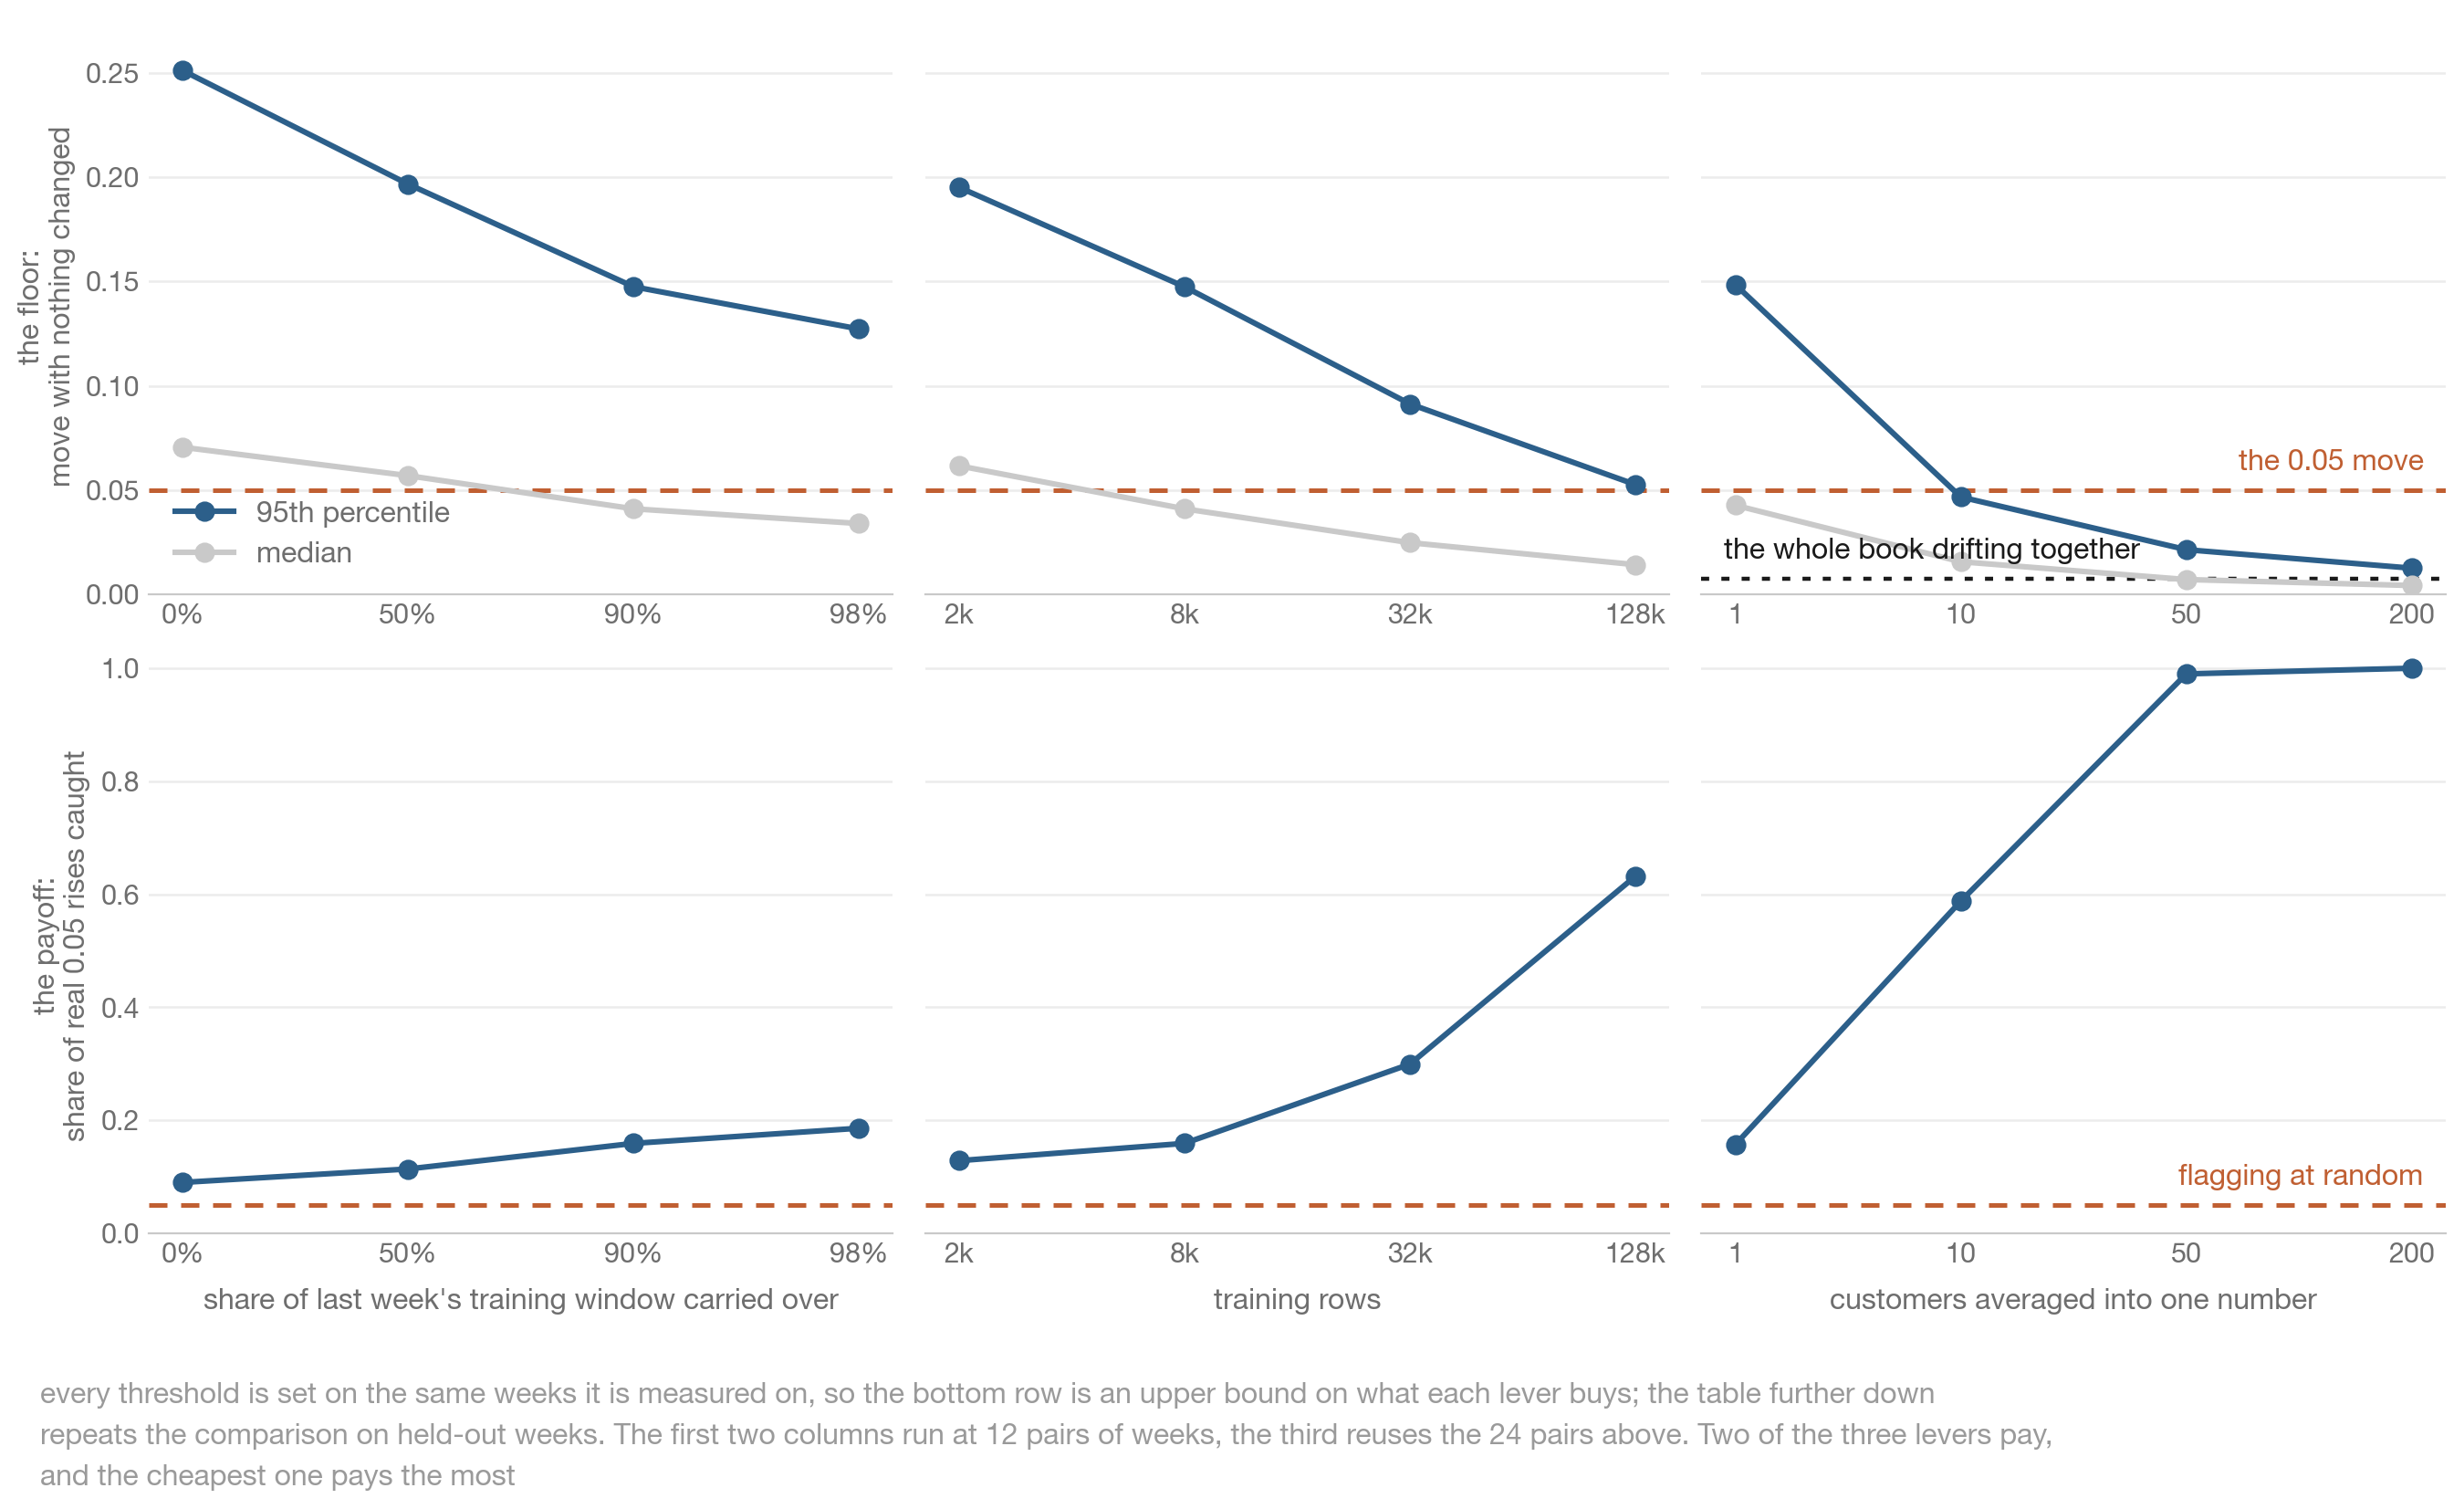

In [10]:
LEVERS = [("window carried over", "share of last week's training window carried over",
           lambda v: f"{v:.0%}"),
          ("training rows", "training rows", lambda v: f"{v / 1000:.0f}k" if v >= 1000 else str(v)),
          ("customers averaged", "customers averaged into one number", lambda v: str(int(v)))]
ymax = 1.1 * lever["95th percentile move"].max()

fig, axes = plt.subplots(2, 3, figsize=(13.6, 7.4), dpi=200)
for col, (name, xlabel, fmt) in enumerate(LEVERS):
    sub = lever[lever.lever == name].reset_index(drop=True)
    x = np.arange(len(sub))
    top, bot = axes[0, col], axes[1, col]
    top.plot(x, sub["95th percentile move"], "o-", color=BLUE_E, lw=2.2, ms=7,
             label="95th percentile", zorder=3)
    top.plot(x, sub["median move"], "o-", color=GREY_E, lw=2.2, ms=7, label="median", zorder=3)
    top.axhline(MOVE, color=CORAL_E, lw=1.8, ls=(0, (4, 3)), zorder=2)
    top.set_ylim(0, ymax)
    bot.plot(x, sub["real rises caught"], "o-", color=BLUE_E, lw=2.2, ms=7, zorder=3)
    bot.axhline(0.05, color=CORAL_E, lw=1.8, ls=(0, (4, 3)), zorder=2)
    bot.set_ylim(0, 1.02)
    bot.set_xlabel(xlabel, fontsize=11.5, color=TEXT_MUTED, labelpad=8)
    for ax in (top, bot):
        ax.set_xticks(x)
        ax.set_xticklabels([fmt(v) for v in sub.level])
        clean(ax)
        ax.tick_params(labelsize=11)
    if col:
        top.set_yticklabels([])
        bot.set_yticklabels([])
axes[0, 0].set_ylabel("the floor:\nmove with nothing changed", fontsize=11.5, color=TEXT_MUTED)
axes[1, 0].set_ylabel(f"the payoff:\nshare of real {MOVE:.2f} rises caught", fontsize=11.5,
                      color=TEXT_MUTED)
axes[0, 0].legend(frameon=False, fontsize=11.5, labelcolor=TEXT_MUTED, loc="lower left")
axes[0, 2].axhline(book, color=INK, lw=1.6, ls=(0, (2, 3)), zorder=2)
for ax, y, colour, at, text in ((axes[0, 2], MOVE, CORAL_E, 0.97, f"the {MOVE:.2f} move"),
                                (axes[1, 2], 0.05, CORAL_E, 0.97, "flagging at random"),
                                (axes[0, 2], book, INK, 0.03,
                                 "the whole book drifting together")):
    ax.annotate(text, (at, y), xycoords=("axes fraction", "data"), xytext=(0, 8),
                textcoords="offset points", fontsize=11.5, color=colour,
                ha="right" if at > 0.5 else "left")
finish(fig, "score_noise_levers.png",
       f"every threshold is set on the same weeks it is measured on, so the bottom row is an "
       f"upper bound on what each lever buys; the table further down\nrepeats the comparison on "
       f"held-out weeks. The first two columns run at {LEVER_PAIRS} pairs of weeks, the third "
       f"reuses the {PAIRS} pairs above. Two of the three levers pay,\nand the cheapest one pays "
       f"the most", y=-0.07)

## Which customers are noisy

If the floor cannot be pushed below five points for everybody, the next question is whether it can
be spent unevenly: a lower bar for the customers whose score is stable and a higher one for the
rest. That needs a per-row quantity that predicts how much a customer's score will move.

The truth to predict is how much a given customer's own score moves from week-pair to week-pair,
measured in the same rolled-window regime the rules will be spent in. Three candidates come from a
single production run:

- the **Venn-Abers width**, the interval itself
- **p(1 - p)**, which costs nothing and is the shape any variance on a probability scale must have
- the **distance to the nearest training row**

A fourth, the same distance over only the three features that drive the probability, is not
something production hands you — it needs to be told which features matter. It is here as a ceiling:
what the distance could do if its metric were not diluted by the two inert features.

`p(1 - p)` is in the list to make the test able to fail. Everything on a probability scale is
squeezed towards zero near 0 and 1, so any two such quantities correlate through that shape alone,
and a predictor knowing nothing but roughly where the score sits will look useful.

So the correlation is also computed inside bands of the score, where that shape is held fixed. Two
cautions come with that. `p(1 - p)` is a deterministic function of the score, rising below 0.5 and
falling above it, so inside a band it can only rank customers the way the score does and its
per-band correlations flip sign either side of 0.5. And a conditional statistic averaged over ten
bands of roughly 195 customers is noisy in its own right. Both are handled the same way: shuffle the
target inside each band, recompute, and report where the statistic lands when the predictor is known
to carry nothing. Every candidate faces the same shuffles.

In [11]:
spread = move.std(axis=0, ddof=1)       # how much each customer's own score moves, week to week
dist0 = NearestNeighbors(n_neighbors=1).fit(Xtr).kneighbors(Xte)[0][:, 0]
drive0 = NearestNeighbors(n_neighbors=1).fit(Xtr[DRIVERS]).kneighbors(Xte[DRIVERS])[0][:, 0]
cands = {"venn-abers width": width0, "p(1 - p)": p0 * (1 - p0),
         "distance to the training set": dist0,
         "distance over the driving features": drive0}

band_of = pd.qcut(p0, 10, labels=False, duplicates="drop")
bands = [np.flatnonzero(band_of == b) for b in np.unique(band_of)]


def within(v, target):
    return np.nanmean([spearmanr(v[b], target[b]).statistic for b in bands])


rng = np.random.default_rng(4)
shuffles = []
for _ in range(PERMUTATIONS):
    shuffled = spread.copy()
    for b in bands:
        shuffled[b] = rng.permutation(shuffled[b])
    shuffles.append(shuffled)

pred = pd.DataFrame(
    [{"predictor": k, "overall": spearmanr(v, spread).statistic,
      "within bands of the score": within(v, spread),
      "chance level": np.quantile([abs(within(v, s)) for s in shuffles], 0.95)}
     for k, v in cands.items()]).set_index("predictor")
print(f"rank correlation with how much a customer's own score moves, over {PAIRS} pairs of weeks")
print(f"conditioned inside {len(bands)} equal-sized bands of the score")
print(f"the chance level is the 95th percentile of the same conditional statistic under "
      f"{PERMUTATIONS} shuffles of the target within each band")
print(pred.round(3).to_string())

rank correlation with how much a customer's own score moves, over 24 pairs of weeks
conditioned inside 10 equal-sized bands of the score
the chance level is the 95th percentile of the same conditional statistic under 200 shuffles of the target within each band
                                    overall  within bands of the score  chance level
predictor                                                                           
venn-abers width                      0.031                     -0.016         0.076
p(1 - p)                              0.278                      0.013         0.077
distance to the training set          0.161                      0.119         0.070
distance over the driving features    0.108                      0.129         0.079


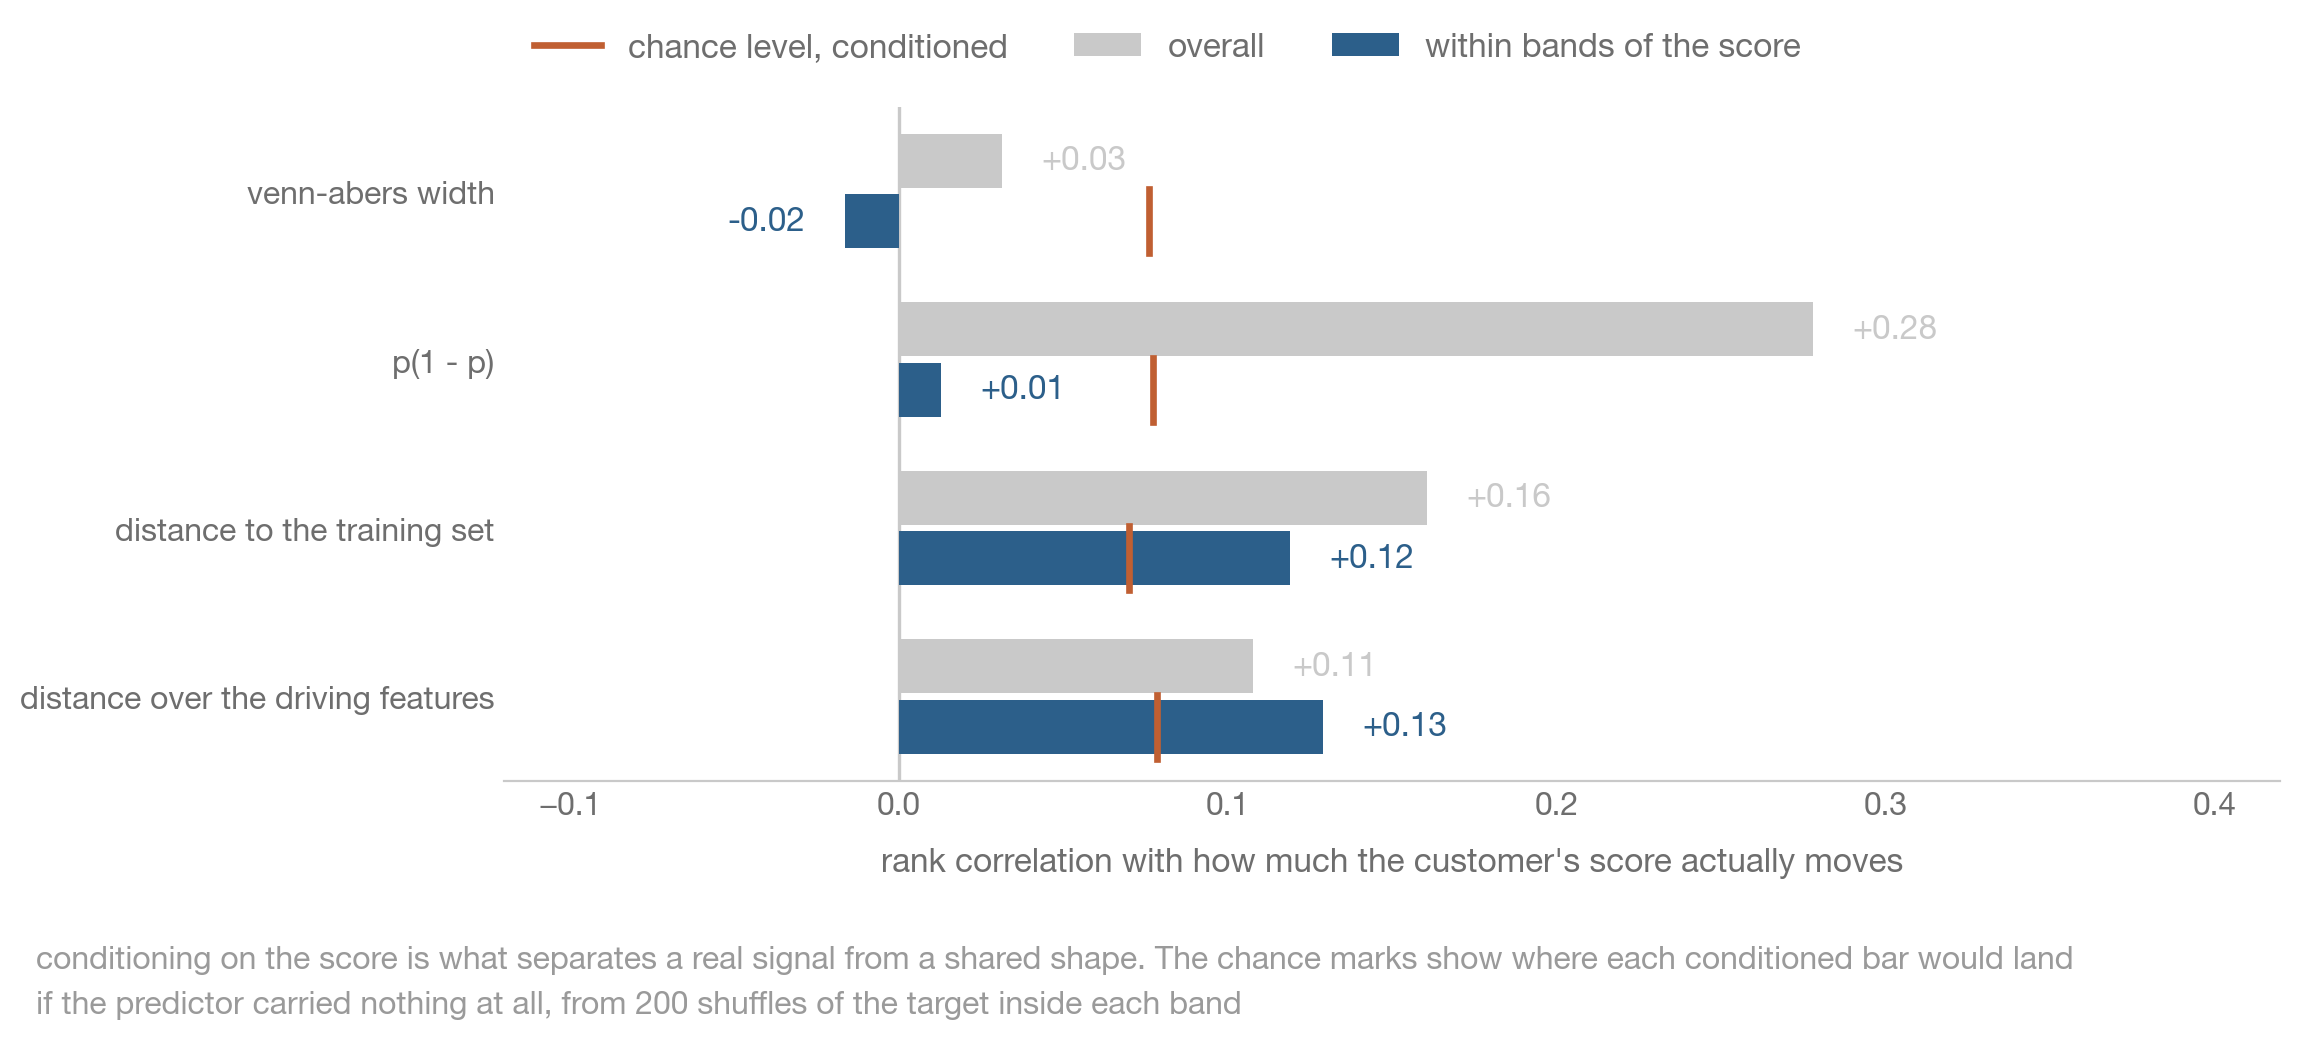

In [12]:
fig, ax = plt.subplots(figsize=(11.6, 4.6), dpi=200)
y = np.arange(len(pred))
for off, col, colour in ((-0.18, "overall", GREY_E),
                         (0.18, "within bands of the score", BLUE_E)):
    ax.barh(y + off, pred[col], height=0.32, color=colour, label=col, zorder=2)
    for yi, v in zip(y + off, pred[col]):
        ax.text(v + (0.012 if v >= 0 else -0.012), yi, f"{v:+.2f}", va="center",
                ha="left" if v >= 0 else "right", fontsize=12, color=colour, zorder=3)
ax.axvline(0, color=GREY_E, lw=1.2, zorder=1)
for i, (yi, c) in enumerate(zip(y + 0.18, pred["chance level"])):
    ax.plot([c, c], [yi - 0.19, yi + 0.19], color=CORAL_E, lw=2.4, zorder=4,
            label="chance level, conditioned" if i == 0 else None)
ax.set_yticks(y)
ax.set_yticklabels(pred.index, fontsize=13, color=INK)
ax.set_ylim(len(pred) - 0.5, -0.5)
ax.set_xlim(-0.12, 0.42)
ax.set_xlabel("rank correlation with how much the customer's score actually moves",
              fontsize=12, color=TEXT_MUTED, labelpad=10)
ax.legend(frameon=False, fontsize=12, labelcolor=TEXT_MUTED, ncol=3,
          loc="lower left", bbox_to_anchor=(0, 1.02))
clean(ax)
ax.grid(False)
finish(fig, "score_noise_predictors.png",
       f"conditioning on the score is what separates a real signal from a shared shape. The chance "
       f"marks show where each conditioned bar would land\nif the predictor carried nothing at all, "
       f"from {PERMUTATIONS} shuffles of the target inside each band")

## Does any of it catch the real move

The levers chart set every threshold on the same weeks it then measured, which flatters all of them.
Here the comparison is done properly: the single scaling constant of each rule is fitted on the
first half of the week pairs, and every rule is measured on the second half, so the false alarm
column is an outcome rather than an identity.

In [13]:
half = PAIRS // 2
tune, check = slice(half), slice(half, None)
rules = {"one threshold for everybody": np.ones(len(Xte)), **cands}

det = []
for name, v in rules.items():
    thr = np.quantile(move[tune] / v, 0.95) * v   # the only thing fitted, on the first half
    det.append({"rule": name, "false alarms": (move[check] > thr).mean(),
                "real rises caught": (rise[check] > thr).mean()})
print(f"thresholds fitted on the first {half} pairs of weeks and measured on the last {half}, "
      f"catching a true {MOVE:.2f} rise")
print(pd.DataFrame(det).set_index("rule").round(3).to_string())

thresholds fitted on the first 12 pairs of weeks and measured on the last 12, catching a true 0.05 rise
                                    false alarms  real rises caught
rule                                                               
one threshold for everybody                0.052              0.155
venn-abers width                           0.053              0.144
p(1 - p)                                   0.051              0.153
distance to the training set               0.052              0.156
distance over the driving features         0.051              0.139


## What this leaves you with

**Measure your own floor before interpreting any individual move.** It is a day of work: refit on a
rolled window, score the same customers twice, look at the spread. The number is a property of your
data and your refresh cadence, and it is the only thing that says whether a move is worth a
conversation.

**Do not read a calibrated interval as the noise in the score.** Venn-Abers is valid for what it
claims and is the right tool for calibration. It is a statement about the mapping from score to
probability, not about how much the score itself would move on the next refit, and here the two
differ by more than an order of magnitude.

**Aggregate.** Averaging customers is the cheapest lever by a wide margin, and it buys more than a
large increase in training data does. It stops paying once a cohort is large enough that what is
left is the whole book drifting together.

**Spend the individual question on the tail.** Of the quantities available from a single run, only
the distance to the training set carries information about which customers are unstable once the
score itself is held fixed, and comparing it with the same distance over the driving features shows
how much of its weakness is the metric rather than the idea. Either way it is enough to rank, not to
threshold, which makes it a way of choosing whose move gets a human rather than a rule that decides
on its own.